In [ ]:
from pathlib import Path

import sys
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    lab_root = Path("/content/drive/MyDrive/Colab Notebooks/DSML/Predictive_Project")
else:
    lab_root = Path(".")

print(f"lab_root set to: {lab_root.resolve()}")

Mounted at /content/drive
lab_root set to: /content/drive/MyDrive/Colab Notebooks/DSML/Predictive_Project


In [ ]:
# import needed libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from scipy.stats import spearmanr
from sklearn.feature_selection import RFE
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LogisticRegressionCV
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import validation_curve


In [ ]:
# Shared execution configuration
RANDOM_SEED = 99
FAST_MODE = False

np.random.seed(RANDOM_SEED)
print(f"Configured RANDOM_SEED={RANDOM_SEED} | FAST_MODE={FAST_MODE}")

Configured RANDOM_SEED=99 | FAST_MODE=False


## Data Quality Inspection

Before cleaning, we inspect the raw data to identify any quality issues.
This drives all the decisions made in the cleaning step that follows.

In [ ]:
train_path = lab_root / "donors_train.csv"
train_target_path = lab_root/"donors_train_target.csv"
test_path  = lab_root / "test.csv"


In [ ]:
# Raw load
train = pd.read_csv(train_path, index_col="CONTROL_NUMBER")
test  = pd.read_csv(test_path,  index_col="CONTROL_NUMBER")

# Inspect the categories of every non-numeric column
categorical_cols = train.select_dtypes(exclude="number").columns
for col in categorical_cols:
    print(f"--- {col} ---")
    print(train[col].value_counts(dropna=False))
    print()

--- DONOR_GENDER ---
DONOR_GENDER
F      7222
M      5376
U       705
NaN     257
Name: count, dtype: int64

--- HOME_OWNER ---
HOME_OWNER
H      7251
U      6041
NaN     268
Name: count, dtype: int64

--- RECENCY_STATUS_96NK ---
RECENCY_STATUS_96NK
A      8202
S      2877
F      1048
N       825
E       283
NaN     266
L        59
Name: count, dtype: int64

--- SES ---
SES
2      6365
1      4091
3      2277
?       292
NaN     286
4       249
Name: count, dtype: int64

--- URBANICITY ---
URBANICITY
S      3103
C      2741
T      2734
R      2732
U      1677
?       295
NaN     278
Name: count, dtype: int64



In [ ]:
# No count, amount, age, income, month, percentage or proportion can be negative:
# any negative value is therefore impossible / corrupted.
numeric_cols = train.select_dtypes("number").columns
negatives_per_col = (train[numeric_cols] < 0).sum()
print(negatives_per_col[negatives_per_col > 0].sort_values(ascending=False))

PCT_ATTRIBUTE4                 77
CHILDREN                       75
RECENT_AVG_GIFT_AMT            75
RECENT_CARD_RESPONSE_COUNT     73
RECENT_STAR_STATUS             73
LIFETIME_PROM                  72
RECENT_CARD_RESPONSE_PROP      71
MONTHS_SINCE_FIRST_GIFT        70
PEP_STAR                       70
MEDIAN_HOUSEHOLD_INCOME        70
LAST_GIFT_AMT                  70
FREQUENCY_STATUS_97NK          70
LIFETIME_GIFT_COUNT            70
LIFETIME_CARD_PROM             68
PER_CAPITA_INCOME              68
RECENT_AVG_CARD_GIFT_AMT       68
NUMBER_PROM_12                 67
RECENT_RESPONSE_PROP           67
WEALTH_RATING                  67
LIFETIME_MAX_GIFT_AMT          67
LIFETIME_GIFT_AMOUNT           66
RECENT_RESPONSE_COUNT          66
PCT_ATTRIBUTE3                 65
LIFETIME_MIN_GIFT_AMT          64
FILE_CARD_GIFT                 64
PCT_ATTRIBUTE1                 63
PCT_ATTRIBUTE2                 62
INCOME_GROUP                   61
MEDIAN_HOME_VALUE              54
MONTHS_SINCE_L

In [ ]:
# Count non-integer values, and the share of integer values, per numeric column.
# Columns that are ~99% integer but contain a couple of non-integer values are corrupted;
# columns that are mostly fractional (averages, proportions) are legitimately non-integer.
for col in numeric_cols:
    x = train[col].dropna()
    n_non_integer = (x % 1 != 0).sum()
    pct_integer = (x % 1 == 0).mean() * 100
    if n_non_integer > 0:
        print(f"{col:28s} non-integers={n_non_integer:4d}  ({pct_integer:5.1f}% integer)")

CARD_PROM_12                 non-integers= 136  ( 99.0% integer)
CHILDREN                     non-integers= 143  ( 98.9% integer)
DONOR_AGE                    non-integers= 138  ( 98.6% integer)
FILE_CARD_GIFT               non-integers= 126  ( 99.1% integer)
FREQUENCY_STATUS_97NK        non-integers= 134  ( 99.0% integer)
INCOME_GROUP                 non-integers= 130  ( 98.7% integer)
LAST_GIFT_AMT                non-integers= 156  ( 98.8% integer)
LIFETIME_CARD_PROM           non-integers= 137  ( 99.0% integer)
LIFETIME_GIFT_AMOUNT         non-integers= 371  ( 97.2% integer)
LIFETIME_GIFT_COUNT          non-integers= 142  ( 98.9% integer)
LIFETIME_MAX_GIFT_AMT        non-integers= 167  ( 98.7% integer)
LIFETIME_MIN_GIFT_AMT        non-integers= 259  ( 98.1% integer)
LIFETIME_PROM                non-integers= 131  ( 99.0% integer)
MEDIAN_HOME_VALUE            non-integers= 120  ( 99.1% integer)
MEDIAN_HOUSEHOLD_INCOME      non-integers= 142  ( 98.9% integer)
MONTHS_SINCE_FIRST_GIFT  

In [ ]:
# Coded columns have a documented valid range; values outside it are corrupted.
documented_ranges = {"INCOME_GROUP": "1-7", "WEALTH_RATING": "0-9", "PEP_STAR": "0-1"}
for col, valid_range in documented_ranges.items():
    print(f"{col:15s} documented={valid_range:5s} | observed: "
          f"min={train[col].min():.2f}  max={train[col].max():.2f}")

INCOME_GROUP    documented=1-7   | observed: min=-1.73  max=9.49
WEALTH_RATING   documented=0-9   | observed: min=-3.75  max=13.45
PEP_STAR        documented=0-1   | observed: min=-0.53  max=2.00


### Findings

The inspection above revealed two data-quality problems:

1. **Hidden missing values**: `SES` and `URBANICITY` use the string `"?"` for missing entries (not recognized as `NaN` by pandas).
2. **Injected corruption**: every numeric column contains a few impossible values — negatives, non-integers in otherwise integer columns, and out-of-range codes.

We address both in the next section: we reload the data treating `"?"` as missing, and map every impossible value to `NaN` so it can be imputed later.

In [ ]:
# Load raw data, treating "?" as missing (hidden NaN in SES and URBANICITY)
def load_raw(path):
    return pd.read_csv(path, index_col="CONTROL_NUMBER", na_values=["?"])

train  = load_raw(train_path)
target = pd.read_csv(train_target_path, index_col="CONTROL_NUMBER")
test   = load_raw(test_path)

# --- Column groups defined by MEANING, not by dtype ---
# Nominal categorical -> one-hot later
nominal_cat = ["DONOR_GENDER", "HOME_OWNER", "URBANICITY", "RECENCY_STATUS_96NK", "SES"]

# Numeric columns that are GENUINELY fractional (averages / proportions):
# here a non-integer value is legitimate, so the "non-integer = corruption" rule must NOT apply
fractional_num = ["RECENT_AVG_GIFT_AMT", "RECENT_AVG_CARD_GIFT_AMT",
                  "RECENT_RESPONSE_PROP", "RECENT_CARD_RESPONSE_PROP"]

# Proportions are bounded in [0, 1]
proportion_num = ["RECENT_RESPONSE_PROP", "RECENT_CARD_RESPONSE_PROP"]

In [ ]:
def clean_impossible_values(df):
    """
    Map injected / impossible values to NaN so they can be imputed later.
    Rules are deterministic (no fitting) -> applying to train and test causes NO leakage.
    """
    df = df.copy()
    numeric_cols = df.select_dtypes("number").columns

    for col in numeric_cols:
        # Rule 1 (universal): no count / amount / age / income / month / percentage
        #                     / proportion can ever be negative
        df.loc[df[col] < 0, col] = np.nan

        # Rule 2: in integer-valued columns, a non-integer value is injected corruption
        if col not in fractional_num:
            non_integer = df[col].notna() & (df[col] % 1 != 0)
            df.loc[non_integer, col] = np.nan

    # Rule 3: proportions cannot exceed 1
    for col in proportion_num:
        df.loc[df[col] > 1, col] = np.nan

    return df

train = clean_impossible_values(train)
test  = clean_impossible_values(test)

# Attach target only to train, aligned on the index
train = train.join(target)

In [ ]:
# Sanity checks after cleaning
num_cols = train.drop(columns="TARGET_B").select_dtypes("number").columns
print("Remaining negative values:", int((train[num_cols] < 0).sum().sum()))   # expected: 0
print("TARGET_B NaN:", int(train["TARGET_B"].isna().sum()))                    # expected: 0
print(train.shape)                                                             # expected: (13560, 40)

Remaining negative values: 0
TARGET_B NaN: 0
(13560, 40)


## Modeling Setup: Preprocessing and Cross-Validation Assessment

We wrap all preprocessing in a `Pipeline` / `ColumnTransformer` so that imputation,
scaling and encoding are fitted **only on the training portion of each CV fold** —
this prevents data leakage automatically.

Assessment strategy: **Stratified 5-fold cross-validation** (stratified because the
target is imbalanced, ~25% positives), scored with the **binary F1** of the competition.

In [ ]:
X = train.drop(columns="TARGET_B")
y = train["TARGET_B"]

# Numeric = everything that is not a nominal categorical column.
# (SES is stored as a number but is a code -> kept in nominal_cat, so it is excluded here.)
numeric_cols = [c for c in X.columns if c not in nominal_cat]
print(f"Numeric features: {len(numeric_cols)} | Categorical features: {len(nominal_cat)}")

Numeric features: 34 | Categorical features: 5


In [ ]:
# Numeric: median imputation (robust to skew) + MinMax scaling
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  MinMaxScaler()),
])

# Categorical: most-frequent imputation + one-hot (ignore categories unseen at fit time)
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe,     numeric_cols),
    ("cat", categorical_pipe, nominal_cat),
])

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def evaluate_model(model, X, y):
    """Stratified 5-fold CV F1. Preprocessing is fit inside each fold -> no leakage."""
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    cv = cross_validate(pipe, X, y, cv=skf, scoring="f1", return_train_score=True)
    return cv["train_score"].mean(), cv["test_score"].mean(), cv["test_score"].std()

In [ ]:
# Baseline: default settings, threshold 0.5, no class weighting -> intentionally naive
baseline_models = {
    "KNN":          KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_SEED),
    "MLP":          MLPClassifier(max_iter=500, early_stopping = True, random_state=RANDOM_SEED),   # slowest one
    "LogReg":       LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
}

print(f"{'model':14s}{'train_F1':>10s}{'val_F1':>9s}{'val_std':>9s}")
for name, model in baseline_models.items():
    tr, va, sd = evaluate_model(model, X, y)
    print(f"{name:14s}{tr:10.3f}{va:9.3f}{sd:9.3f}")

model           train_F1   val_F1  val_std
KNN                0.398    0.178    0.011
DecisionTree       1.000    0.291    0.011
MLP                0.020    0.016    0.021
LogReg             0.028    0.024    0.012


### Baseline Results (naive setup)

These four models are run with **default settings, a 0.5 decision threshold, and no class weighting** — intentionally naive, to establish an honest starting point before any optimization.

All four score **below the trivial baseline of F1 = 0.40** (the F1 obtained by predicting "donor" for everyone). This is a direct consequence of the class imbalance: with only ~25% positives and a 0.5 threshold, the models minimize error by predicting the majority class (non-donor) most of the time. They therefore produce very few positive predictions, which yields low recall on the positive class and collapses the F1. Logistic Regression is the extreme case (val F1 ≈ 0.02): it predicts almost everyone as non-donor.

The Decision Tree shows the highest validation F1 (≈ 0.29), but this should **not** be read as the best model. Its train F1 of 1.000 against a val F1 of 0.29 reveals severe overfitting: an unconstrained tree memorizes the training data through pure leaves but generalizes poorly. Its comparatively higher validation F1 is a side effect of overfitting (it makes more positive predictions and partly escapes the "predict-all-zero" collapse), not genuine quality.

**Conclusion.** This baseline is not a model comparison but a diagnosis: the imbalance, combined with the default threshold, prevents the models from being useful as-is. In the next steps we address this directly and uniformly across all models — using `class_weight="balanced"` and tuning the decision threshold to maximize F1 — so that the models can be compared on a fair footing.

In [ ]:
def oof_probabilities(model):
    """Out-of-fold positive-class probabilities (each sample scored by a model that never saw it)."""
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    return cross_val_predict(pipe, X, y, cv=skf, method="predict_proba")[:, 1]

def best_f1_threshold(proba, y_true):
    """Decision threshold that maximizes F1 on the precision-recall curve."""
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    denominator = precision + recall
    f1s = np.divide(2 * precision * recall, denominator,
                    out=np.zeros_like(denominator), where=denominator > 0)
    ix = np.argmax(f1s[:-1])
    return thresholds[ix], f1s[ix]

In [ ]:
# KNN and MLP do not support class_weight -> their "weighted" entry is None
candidate_models = {
    "KNN":          {"base": KNeighborsClassifier(), "weighted": None},
    "DecisionTree": {"base": DecisionTreeClassifier(random_state=RANDOM_SEED), "weighted": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_SEED)},
    "MLP":          {"base": MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_SEED), "weighted": None},
    "LogReg":       {"base": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED), "weighted": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)},
}

rows = []
for name, spec in candidate_models.items():
    proba_base = oof_probabilities(spec["base"])
    f1_base = f1_score(y, (proba_base >= 0.5).astype(int))

    if spec["weighted"] is not None:
        proba_lever = oof_probabilities(spec["weighted"])
        f1_weighted = f1_score(y, (proba_lever >= 0.5).astype(int))
    else:
        proba_lever, f1_weighted = proba_base, np.nan      # class_weight not applicable

    thr, f1_tuned = best_f1_threshold(proba_lever, y)
    rows.append([name, f1_base, f1_weighted, f1_tuned, thr])

comparison = (pd.DataFrame(rows, columns=["model", "F1_base_0.5", "F1_weighted_0.5",
                                          "F1_tuned", "best_threshold"])
                .round(3).sort_values("F1_tuned", ascending=False).reset_index(drop=True))
comparison

,model,F1_base_0.5,F1_weighted_0.5,F1_tuned,best_threshold
0,LogReg,0.024,0.406,0.419,0.434
1,MLP,0.016,NaN,0.415,0.222
2,DecisionTree,0.291,0.279,0.400,0.000
3,KNN,0.178,NaN,0.400,0.000


### Lever Comparison: Results

For each model we applied the two levers for imbalanced F1 — `class_weight="balanced"`
(where supported) and tuning the decision threshold to maximize F1 — and assessed every
configuration with the same out-of-fold cross-validation protocol. The MLP uses
`early_stopping=True`, which acts as a regularizer (it halts training once the internal
validation score plateaus) and, as a side benefit, trains far faster and converges cleanly.

The picture is now clear:

- **Logistic Regression (F1 ≈ 0.42)** and the **MLP (F1 ≈ 0.42)** are the genuine leaders.
  Both produce well-spread probability estimates, so threshold tuning settles on meaningful
  values (≈ 0.43 and ≈ 0.22 respectively) that truly beat the trivial baseline of 0.40.

- **The Decision Tree and KNN tune to a degenerate threshold of ≈ 0.000**, i.e. they merely
  recover the "predict everyone" baseline (F1 = 0.40). At their default hyperparameters their
  probabilities do not separate the classes — the unconstrained tree returns near-0/1 values
  from pure leaves, and KNN with k=5 returns only coarse fractions. Class weighting does not
  help (it slightly worsens the tree: 0.291 → 0.279).

**Takeaway.** Threshold tuning only pays off when a model emits informative probabilities.
Logistic Regression and the MLP already clear the baseline; the Decision Tree and KNN must
first be regularized (tree depth, number of neighbours) before the lever becomes useful.
This sets up the next stage: feature selection and hyperparameter optimization.

## Feature Selection

We have 34 numeric and 5 categorical features, several of which are likely redundant or
uninformative. We combine **filter**, **wrapper**
and **embedded** methods rather than relying on a single one, and we read their results
together to build a defensible shortlist of predictors. All selection is performed on the
**training data only** (the test set stays untouched).

The numeric block is screened in two coordinated steps:

1. **Spearman correlation — redundancy removal.** We compute the pairwise
   Spearman correlation between the numeric features and flag every pair with |r| > 0.8.
   Spearman (rank-based) is preferred over Pearson here because our monetary and count
   features are heavily right-skewed and contain outliers: it captures monotonic
   relationships without being distorted by extreme values. Highly correlated features carry
   essentially the same information, so keeping all of them adds noise and hurts the models
   most sensitive to dimensionality (KNN, MLP).

2. **Decision-tree feature importance — tie-breaking.** Correlation tells us
   *which groups* are redundant, but not *which member* to keep. For each highly correlated
   group we retain the feature with the highest decision-tree importance and drop the others,
   so the decision is data-driven rather than arbitrary.

We then confirm the resulting shortlist with wrapper/embedded methods (RFE and Lasso) before
fixing the final feature set used for modeling.

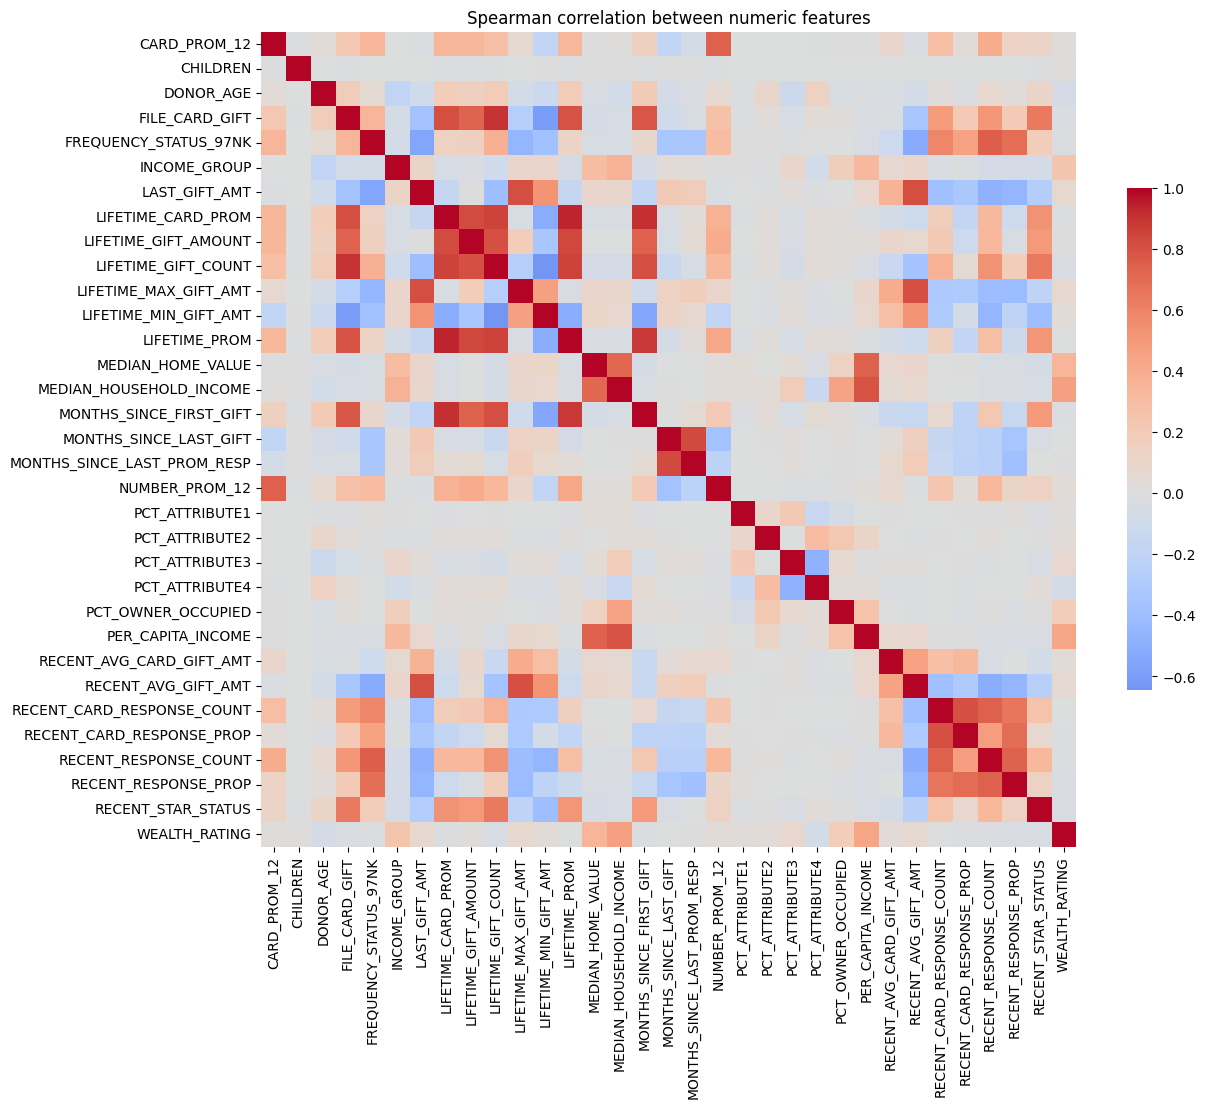

In [ ]:
# Spearman is appropriate for ordered/continuous variables, so we exclude
# nominal categoricals (handled by chi-square) and binary flags.
binary_flags = ["PEP_STAR"]
spearman_cols = [c for c in numeric_cols if c not in binary_flags]

# Median-impute (correlation cannot handle NaN), then compute the Spearman matrix
X_num_imputed = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X[spearman_cols]),
    columns=spearman_cols, index=X.index,
)
corr = X_num_imputed.corr(method="spearman")

# Heatmap
plt.figure(figsize=(13, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=True)
plt.title("Spearman correlation between numeric features")
plt.tight_layout()
plt.show()

### Spearman Correlation — Redundant Predictors (|r| > 0.8)

We compute the Spearman correlation inside each cross-validation fold so that our conclusions
do not depend on a single split. The table below lists every pair of numeric features whose
mean absolute correlation across folds exceeds 0.8. The values are essentially identical
across all five splits, confirming that these redundancies are stable properties of the data.

These pairs form a few strongly correlated groups:
- **Engagement / longevity:** `LIFETIME_CARD_PROM`, `LIFETIME_PROM`, `LIFETIME_GIFT_COUNT`, `LIFETIME_GIFT_AMOUNT`, `MONTHS_SINCE_FIRST_GIFT`, `FILE_CARD_GIFT`
- **Gift size:** `LAST_GIFT_AMT`, `LIFETIME_MAX_GIFT_AMT`, `RECENT_AVG_GIFT_AMT`
- **Recency:** `MONTHS_SINCE_LAST_GIFT`, `MONTHS_SINCE_LAST_PROM_RESP`
- **Card response:** `RECENT_CARD_RESPONSE_COUNT`, `RECENT_CARD_RESPONSE_PROP`

We use decision-tree importance next to decide which variable to keep from each correlated
group before moving to the regression-based methods (RFE and Lasso).

In [ ]:
fold_correlations = []
for train_idx, _ in skf.split(X, y):
    X_fold = pd.DataFrame(
        SimpleImputer(strategy="median").fit_transform(X.iloc[train_idx][spearman_cols]),
        columns=spearman_cols,
    )
    fold_correlations.append(X_fold.corr(method="spearman"))

# Keep the pairs whose mean absolute correlation across folds exceeds 0.8
threshold = 0.8
records = []
for i in range(len(spearman_cols)):
    for j in range(i + 1, len(spearman_cols)):
        per_split = [fc.iloc[i, j] for fc in fold_correlations]
        if np.mean(np.abs(per_split)) > threshold:
            records.append([f"{spearman_cols[i]} Vs {spearman_cols[j]}"] +
                           [round(v, 3) for v in per_split])

split_names = [f"Split {k}" for k in range(1, skf.get_n_splits() + 1)]
redundancy_table = pd.DataFrame(records, columns=["Combination"] + split_names)
redundancy_table["max_abs"] = redundancy_table[split_names].abs().max(axis=1)
redundancy_table = (redundancy_table.sort_values("max_abs", ascending=False)
                                    .drop(columns="max_abs").reset_index(drop=True))
redundancy_table

,Combination,Split 1,Split 2,Split 3,Split 4,Split 5
0,LIFETIME_CARD_PROM Vs LIFETIME_PROM,0.941,0.943,0.942,0.942,0.942
1,LIFETIME_CARD_PROM Vs MONTHS_SINCE_FIRST_GIFT,0.905,0.903,0.904,0.904,0.902
2,FILE_CARD_GIFT Vs LIFETIME_GIFT_COUNT,0.900,0.901,0.899,0.900,0.900
3,LIFETIME_PROM Vs MONTHS_SINCE_FIRST_GIFT,0.886,0.885,0.886,0.886,0.885
4,LIFETIME_CARD_PROM Vs LIFETIME_GIFT_COUNT,0.855,0.855,0.856,0.853,0.853
5,LIFETIME_GIFT_COUNT Vs LIFETIME_PROM,0.852,0.854,0.853,0.853,0.851
6,LIFETIME_GIFT_AMOUNT Vs LIFETIME_PROM,0.832,0.833,0.833,0.832,0.834
7,MONTHS_SINCE_LAST_GIFT Vs MONTHS_SINCE_LAST_PR...,0.831,0.830,0.828,0.830,0.833
8,LIFETIME_CARD_PROM Vs LIFETIME_GIFT_AMOUNT,0.822,0.820,0.822,0.819,0.823
9,LIFETIME_GIFT_COUNT Vs MONTHS_SINCE_FIRST_GIFT,0.817,0.819,0.817,0.817,0.816


### Decision-Tree Importance — Which Feature to Keep in Each Group

For each redundant group found above, we decide which feature to keep by comparing decision-tree
importances computed inside each CV fold (per-split, so we can judge their stability). Within a
group we keep the feature with the highest mean importance and drop the others.

The ranking is stable and clear for three of the four groups. The "recency" group is borderline,
so that choice is provisional and will be re-examined with the regression-based methods (RFE and Lasso).

In [ ]:
# Groups read directly from the redundancy_table above
# (connected components of the |r| > 0.8 pairs)
redundant_groups = {
    "engagement/longevity": ["LIFETIME_CARD_PROM", "LIFETIME_PROM", "FILE_CARD_GIFT",
                             "LIFETIME_GIFT_COUNT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_AMOUNT"],
    "gift size":            ["LAST_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "RECENT_AVG_GIFT_AMT"],
    "recency":              ["MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_LAST_PROM_RESP"],
    "card response":        ["RECENT_CARD_RESPONSE_COUNT", "RECENT_CARD_RESPONSE_PROP"],
}

In [ ]:
# Decision-tree importance computed INSIDE each CV fold (per-split, like the Spearman step),
# so we can see whether the ranking within each redundant group is stable across folds.
per_fold_importance = {}
for k, (train_idx, _) in enumerate(skf.split(X, y), start=1):
    X_fold = pd.DataFrame(
        SimpleImputer(strategy="median").fit_transform(X.iloc[train_idx][numeric_cols]),
        columns=numeric_cols,
    )
    tree = DecisionTreeClassifier(random_state=RANDOM_SEED).fit(X_fold, y.iloc[train_idx])
    per_fold_importance[f"Split {k}"] = pd.Series(tree.feature_importances_, index=numeric_cols)

importance_df = pd.DataFrame(per_fold_importance)
importance_df["Mean"] = importance_df.mean(axis=1)

# For each redundant group, show the per-fold importance of its members (sorted by mean)
group_tables = []
for name, group in redundant_groups.items():
    sub = importance_df.loc[group].sort_values("Mean", ascending=False).round(4)
    sub.insert(0, "Group", name)
    group_tables.append(sub)
importance_by_group = pd.concat(group_tables)
importance_by_group

,Group,Split 1,Split 2,Split 3,Split 4,Split 5,Mean
LIFETIME_GIFT_AMOUNT,engagement/longevity,0.0390,0.0383,0.0418,0.0417,0.0439,0.0409
LIFETIME_PROM,engagement/longevity,0.0329,0.0312,0.0346,0.0317,0.0403,0.0342
MONTHS_SINCE_FIRST_GIFT,engagement/longevity,0.0319,0.0336,0.0326,0.0326,0.0316,0.0324
LIFETIME_CARD_PROM,engagement/longevity,0.0169,0.0249,0.0229,0.0238,0.0274,0.0232
LIFETIME_GIFT_COUNT,engagement/longevity,0.0264,0.0161,0.0209,0.0267,0.0229,0.0226
FILE_CARD_GIFT,engagement/longevity,0.0213,0.0191,0.0194,0.0213,0.0188,0.0200
RECENT_AVG_GIFT_AMT,gift size,0.0402,0.0299,0.0348,0.0343,0.0342,0.0347
LAST_GIFT_AMT,gift size,0.0263,0.0200,0.0259,0.0260,0.0226,0.0242
LIFETIME_MAX_GIFT_AMT,gift size,0.0202,0.0186,0.0218,0.0127,0.0229,0.0192
MONTHS_SINCE_LAST_GIFT,recency,0.0276,0.0249,0.0335,0.0215,0.0249,0.0265


In [ ]:
# Keep the highest-mean-importance feature per group, drop the rest
redundant_to_drop = []
for name, group in redundant_groups.items():
    ranked = importance_df.loc[group, "Mean"].sort_values(ascending=False)
    keep, drop = ranked.index[0], list(ranked.index[1:])
    redundant_to_drop += drop
    print(f"[{name}] keep '{keep}' -> drop {drop}")

[engagement/longevity] keep 'LIFETIME_GIFT_AMOUNT' -> drop ['LIFETIME_PROM', 'MONTHS_SINCE_FIRST_GIFT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_COUNT', 'FILE_CARD_GIFT']
[gift size] keep 'RECENT_AVG_GIFT_AMT' -> drop ['LAST_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT']
[recency] keep 'MONTHS_SINCE_LAST_GIFT' -> drop ['MONTHS_SINCE_LAST_PROM_RESP']
[card response] keep 'RECENT_CARD_RESPONSE_PROP' -> drop ['RECENT_CARD_RESPONSE_COUNT']


### Recursive Feature Elimination (RFE) — Wrapper Method

RFE is applied to the redundancy-reduced numeric set, since regression-based methods are
sensitive to multicollinearity. Using Logistic Regression as the estimator, RFE recursively
removes the least useful feature; we run it inside each fold and report the resulting rank of
every feature (rank 1 = retained longest / most useful). A low and stable mean rank indicates
a consistently informative predictor. RFE judges features through a linear model, so it offers
a complementary view to the tree-based importance — disagreements between the two are expected
and informative.

In [ ]:
reduced_numeric = [c for c in numeric_cols if c not in redundant_to_drop]

rfe_ranks = {}
for k, (train_idx, _) in enumerate(skf.split(X, y), start=1):
    X_fold = X.iloc[train_idx][reduced_numeric]
    X_fold = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_fold), columns=reduced_numeric)
    X_fold = pd.DataFrame(MinMaxScaler().fit_transform(X_fold), columns=reduced_numeric)
    rfe = RFE(estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
              n_features_to_select=1).fit(X_fold, y.iloc[train_idx])
    rfe_ranks[f"Split {k}"] = pd.Series(rfe.ranking_, index=reduced_numeric)

rfe_table = pd.DataFrame(rfe_ranks)
rfe_table["Mean rank"] = rfe_table.mean(axis=1)
rfe_table = rfe_table.sort_values("Mean rank")
rfe_table

,Split 1,Split 2,Split 3,Split 4,Split 5,Mean rank
RECENT_AVG_GIFT_AMT,1,3,1,2,1,1.6
PER_CAPITA_INCOME,4,7,3,3,2,3.8
MONTHS_SINCE_LAST_GIFT,5,4,6,5,4,4.8
RECENT_RESPONSE_COUNT,3,1,16,1,3,4.8
MEDIAN_HOME_VALUE,6,5,7,6,6,6.0
FREQUENCY_STATUS_97NK,7,8,8,7,7,7.4
RECENT_CARD_RESPONSE_PROP,8,6,9,10,10,8.6
DONOR_AGE,9,10,12,8,8,9.4
INCOME_GROUP,10,12,10,9,9,10.0
LIFETIME_GIFT_AMOUNT,2,17,2,15,16,10.4


### L1-Penalized Logistic Regression — Embedded Method

As our embedded method we use L1-penalized Logistic Regression, the classification analog of
Lasso: the L1 penalty drives weak coefficients to exactly zero, performing selection during
fitting. We exclude the binary predictor `PEP_STAR`, and the regularization strength is chosen
by cross-validation using ROC AUC — a threshold-independent metric that, unlike F1 at a fixed
threshold, cannot be maximized by predicting a single class. A coefficient of zero means the
feature was dropped; the "N selected" column counts how many folds retained it.

In [ ]:
l1_cols = [c for c in reduced_numeric if c != "PEP_STAR"]   # exclude binary predictor

l1_coefs = {}
for k, (train_idx, _) in enumerate(skf.split(X, y), start=1):
    X_fold = X.iloc[train_idx][l1_cols]
    X_fold = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_fold), columns=l1_cols)
    X_fold = pd.DataFrame(MinMaxScaler().fit_transform(X_fold), columns=l1_cols)
    model = LogisticRegressionCV(Cs=10, penalty="l1", solver="liblinear", scoring="roc_auc",
                                 max_iter=2000, random_state=RANDOM_SEED).fit(X_fold, y.iloc[train_idx])
    l1_coefs[f"Split {k}"] = pd.Series(np.abs(model.coef_[0]), index=l1_cols)

l1_table = pd.DataFrame(l1_coefs)
split_cols = [f"Split {k}" for k in range(1, skf.get_n_splits() + 1)]
l1_table["N selected"] = (l1_table[split_cols] > 1e-6).sum(axis=1)
l1_table["Mean |coef|"] = l1_table[split_cols].mean(axis=1)
l1_table = l1_table.round(3).sort_values("Mean |coef|", ascending=False)
l1_table

,Split 1,Split 2,Split 3,Split 4,Split 5,N selected,Mean |coef|
RECENT_AVG_GIFT_AMT,3.330,2.666,3.598,1.335,4.180,5,3.022
LIFETIME_GIFT_AMOUNT,3.312,1.767,1.726,0.000,2.806,4,1.922
LIFETIME_MIN_GIFT_AMT,1.477,1.349,3.067,0.000,1.247,4,1.428
MONTHS_SINCE_LAST_GIFT,0.929,0.761,0.821,0.749,0.896,5,0.831
PER_CAPITA_INCOME,0.614,0.792,1.205,0.000,0.624,4,0.647
RECENT_AVG_CARD_GIFT_AMT,0.667,0.657,0.620,0.000,1.174,4,0.624
MEDIAN_HOME_VALUE,0.490,0.716,0.692,0.576,0.551,5,0.605
RECENT_RESPONSE_COUNT,0.412,0.411,0.257,0.709,0.624,5,0.483
FREQUENCY_STATUS_97NK,0.367,0.420,0.333,0.417,0.315,5,0.370
RECENT_CARD_RESPONSE_PROP,0.355,0.451,0.361,0.353,0.301,5,0.364


### Categorical Feature Selection — Chi-Square and Mutual Information

For the categorical features we combine two complementary tests, computed inside each CV fold:
the **chi-square** test of association with the target (a feature is significant when p < 0.05),
and **mutual information**, which captures non-linear association and is native to classification.
Missing values are treated as their own category so no rows are discarded. The two methods agree
on the ranking, which strengthens the conclusion.

In [ ]:
chi2_pvalues = {c: [] for c in nominal_cat}
mi_scores    = {c: [] for c in nominal_cat}

for train_idx, _ in skf.split(X, y):
    X_fold = X.iloc[train_idx][nominal_cat].astype(str).fillna("Missing")
    y_fold = y.iloc[train_idx]

    for c in nominal_cat:                                   # chi-square per feature
        contingency = pd.crosstab(X_fold[c], y_fold)
        chi2_pvalues[c].append(chi2_contingency(contingency)[1])

    X_encoded = X_fold.apply(lambda s: pd.factorize(s)[0])  # mutual information (discrete)
    mi = mutual_info_classif(X_encoded, y_fold, discrete_features=True, random_state=RANDOM_SEED)
    for c, v in zip(nominal_cat, mi):
        mi_scores[c].append(v)

categorical_fs = pd.DataFrame({
    "Chi2: N significant (/5)": {c: sum(p < 0.05 for p in chi2_pvalues[c]) for c in nominal_cat},
    "Chi2 mean p-value":        {c: np.mean(chi2_pvalues[c]) for c in nominal_cat},
    "MI mean":                  {c: np.mean(mi_scores[c]) for c in nominal_cat},
}).sort_values("MI mean", ascending=False)
categorical_fs

,Chi2: N significant (/5),Chi2 mean p-value,MI mean
RECENCY_STATUS_96NK,5,1.906692e-21,0.005159
SES,5,2.437166e-04,0.001125
URBANICITY,3,5.621214e-02,0.000525
HOME_OWNER,1,1.482042e-01,0.000226
DONOR_GENDER,0,6.717553e-01,0.000071


### Feature Selection — Synthesis Table

We combine all methods into a single decision table. Each method is expressed as "N YES /5":
DT (importance above the fold mean), RFE (feature in the fold's top-13), L1 (non-zero coefficient),
Chi-square (p < 0.05). Two caveats guide the verdict: L1 retained almost every feature here (light
AUC-tuned regularization), so its binary vote is weak and the verdict relies mainly on DT and RFE;
and DT impurity importance under-rates low-cardinality codes and proportions, so where RFE selects a
feature strongly but DT scores it 0, we follow RFE.

Verdict rule — numeric: KEEP if RFE ≥ 4, or DT ≥ 4 and RFE ≥ 3; REMOVE if DT ≤ 1 and RFE ≤ 1;
otherwise "Try with/without". Categorical: KEEP if Chi-square significant in ≥ 4 folds, REMOVE if ≤ 1,
otherwise "Try". Redundant features removed earlier are listed with the predictor they duplicate.

In [ ]:
kept_for = {  # which kept feature each redundant one duplicates
    'LIFETIME_PROM':'LIFETIME_GIFT_AMOUNT','MONTHS_SINCE_FIRST_GIFT':'LIFETIME_GIFT_AMOUNT',
    'LIFETIME_CARD_PROM':'LIFETIME_GIFT_AMOUNT','LIFETIME_GIFT_COUNT':'LIFETIME_GIFT_AMOUNT',
    'FILE_CARD_GIFT':'LIFETIME_GIFT_AMOUNT','LAST_GIFT_AMT':'RECENT_AVG_GIFT_AMT',
    'LIFETIME_MAX_GIFT_AMT':'RECENT_AVG_GIFT_AMT','MONTHS_SINCE_LAST_PROM_RESP':'MONTHS_SINCE_LAST_GIFT',
    'RECENT_CARD_RESPONSE_COUNT':'RECENT_CARD_RESPONSE_PROP'}
l1_cols = [c for c in reduced_numeric if c != "PEP_STAR"]
K = 13

dt_yes={c:0 for c in reduced_numeric}; rfe_yes={c:0 for c in reduced_numeric}; l1_yes={c:0 for c in l1_cols}
for train_idx,_ in skf.split(X,y):
    Xn=pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X.iloc[train_idx][reduced_numeric]),columns=reduced_numeric)
    imp=pd.Series(DecisionTreeClassifier(random_state=RANDOM_SEED).fit(Xn,y.iloc[train_idx]).feature_importances_,index=reduced_numeric)
    for c in reduced_numeric:
        if imp[c]>imp.mean(): dt_yes[c]+=1
    Xs=pd.DataFrame(MinMaxScaler().fit_transform(Xn),columns=reduced_numeric)
    rfe=RFE(LogisticRegression(max_iter=1000,random_state=RANDOM_SEED),n_features_to_select=K).fit(Xs,y.iloc[train_idx])
    for c,s in zip(reduced_numeric,rfe.support_):
        if s: rfe_yes[c]+=1
    l1=LogisticRegressionCV(Cs=10,penalty="l1",solver="liblinear",scoring="roc_auc",max_iter=2000,random_state=RANDOM_SEED).fit(Xs[l1_cols],y.iloc[train_idx])
    for c,co in zip(l1_cols,l1.coef_[0]):
        if abs(co)>1e-6: l1_yes[c]+=1
chi_yes={c:sum(chi2_contingency(pd.crosstab(X.iloc[tr][c].astype(str).fillna("Missing"),y.iloc[tr]))[1]<0.05
               for tr,_ in skf.split(X,y)) for c in nominal_cat}

def num_verdict(dt,rfe): return "KEEP" if (rfe>=4 or (dt>=4 and rfe>=3)) else ("REMOVE" if (dt<=1 and rfe<=1) else "Try with/without")
def cat_verdict(ch):     return "KEEP" if ch>=4 else ("REMOVE" if ch<=1 else "Try with/without")

rows=[[c,dt_yes[c],rfe_yes[c],l1_yes.get(c,"n/a"),"-",num_verdict(dt_yes[c],rfe_yes[c])] for c in reduced_numeric]
rows+=[[c,"-","-","-",chi_yes[c],cat_verdict(chi_yes[c])] for c in nominal_cat]
rows+=[[c,"-","-","-","-",f"REMOVE (redundant w/ {kept_for[c]})"] for c in redundant_to_drop]
synthesis = pd.DataFrame(rows,columns=["Feature","DT","RFE","L1","Chi2","Verdict"])
synthesis["_o"]=synthesis["Verdict"].map(lambda v:0 if v=="KEEP" else (1 if v.startswith("Try") else 2))
synthesis = synthesis.sort_values(["_o","Feature"]).drop(columns="_o").reset_index(drop=True)
synthesis

,Feature,DT,RFE,L1,Chi2,Verdict
0,DONOR_AGE,5,5,5,-,KEEP
1,FREQUENCY_STATUS_97NK,0,5,5,-,KEEP
2,INCOME_GROUP,0,5,5,-,KEEP
3,MEDIAN_HOME_VALUE,5,5,5,-,KEEP
4,MEDIAN_HOUSEHOLD_INCOME,5,3,4,-,KEEP
5,MONTHS_SINCE_LAST_GIFT,3,5,5,-,KEEP
6,PCT_ATTRIBUTE2,5,3,5,-,KEEP
7,PER_CAPITA_INCOME,5,5,4,-,KEEP
8,RECENCY_STATUS_96NK,-,-,-,5,KEEP
9,RECENT_AVG_GIFT_AMT,5,5,5,-,KEEP


### Interpreting the Synthesis: Which Features We Keep and Why

The verdict for each feature is not based on a single method but on reading all methods together,
**accounting for the known weakness of each one**:

- **Decision-tree importance is biased by cardinality.** Impurity-based importance *inflates*
  continuous, high-cardinality features (they offer many split points) and *deflates* low-cardinality
  discrete codes. We therefore treat a DT score as unreliable *in both directions*: a high DT score on
  a continuous feature and a near-zero DT score on a discrete code are both likely artifacts of this bias.
- **L1 selection was non-discriminating here.** With the light AUC-tuned regularization, L1 retained
  almost every feature, so a non-zero L1 coefficient is weak evidence on its own.

As a result, the verdict relies mainly on **RFE** — the discriminating, bias-free reference — cross-checked
by the others, and treats agreement between methods as the strongest evidence.

**KEEP** — supported by the reliable methods:
- *Unanimous* (DT, RFE and L1 all high): `RECENT_AVG_GIFT_AMT`, `MEDIAN_HOME_VALUE`, `PER_CAPITA_INCOME`,
  `DONOR_AGE` — the most confident keeps, found useful by both a tree and a linear model.
- *Discrete codes with DT = 0 but RFE and L1 high*: `FREQUENCY_STATUS_97NK`, `INCOME_GROUP`,
  `RECENT_RESPONSE_COUNT`. The DT zero is the cardinality-deflation artifact, not genuine uselessness;
  two reliable methods select them.
- *Categoricals significant in every fold*: `RECENCY_STATUS_96NK`, `SES`.

**Try with/without** — genuine method disagreement: continuous features with a high (likely inflated)
DT score but low RFE, e.g. `LIFETIME_GIFT_AMOUNT`, `PCT_ATTRIBUTE4`, `RECENT_RESPONSE_PROP`. We neither
trust the inflated DT score nor discard the feature outright — their value is decided empirically.

**REMOVE** — rejected by the discriminating methods (DT and RFE both low): `CHILDREN`, `NUMBER_PROM_12`,
`RECENT_STAR_STATUS`, `WEALTH_RATING` (also 47% missing), plus the weak categoricals `DONOR_GENDER` and
`HOME_OWNER`. Redundant features are removed because they duplicate a kept predictor (|Spearman| > 0.8).

This classification is confirmed empirically: adding the "Try" features to the confident `keep` set
changes cross-validated F1 by at most 0.003, so we proceed with `keep`.

### From Synthesis to Candidate Feature Sets

At this stage several interpretations remain defensible. Rather than committing to one feature
set, we carry two forward and let the modeling phase decide between them, exactly where the
cross-validated F1 assessment lives:

- **`keep_features`**: the predictors confirmed as strong across the discriminating methods
  (DT and RFE), plus the two categorical predictors significant in every fold.
- **`all_features`**: the core set plus the uncertain ("Try with/without") predictors.

We do not use the lenient "important at least once" rule here, because our L1 method retained
almost every feature (light regularization) and would keep nearly everything. The features marked
REMOVE are rejected by both discriminating methods (and the redundant ones duplicate a kept feature),
so they are excluded from both sets.

In [ ]:
# Core predictors we are confident about (Verdict = KEEP)
keep_features = [
    "RECENT_AVG_GIFT_AMT", "MONTHS_SINCE_LAST_GIFT", "RECENT_CARD_RESPONSE_PROP",
    "RECENT_RESPONSE_COUNT", "FREQUENCY_STATUS_97NK", "INCOME_GROUP", "DONOR_AGE",
    "MEDIAN_HOME_VALUE", "MEDIAN_HOUSEHOLD_INCOME", "PER_CAPITA_INCOME", "PCT_ATTRIBUTE2",
    "RECENCY_STATUS_96NK", "SES",
]

# Uncertain predictors to test during modeling (Verdict = Try with/without)
try_features = [
    "LIFETIME_GIFT_AMOUNT", "LIFETIME_MIN_GIFT_AMT", "RECENT_AVG_CARD_GIFT_AMT",
    "CARD_PROM_12", "RECENT_RESPONSE_PROP", "PEP_STAR",
    "PCT_ATTRIBUTE1", "PCT_ATTRIBUTE3", "PCT_ATTRIBUTE4", "PCT_OWNER_OCCUPIED",
    "URBANICITY",
]

all_features = keep_features + try_features   # core + uncertain, decided during modeling

In [ ]:
# Checkpoint: save the cleaned + feature-selected data (NaN preserved, NOT imputed/scaled).
# Imputation/scaling stay inside the modeling pipeline -> no leakage.
all_data  = train[all_features + ["TARGET_B"]].copy()   # train: core + uncertain + target
test_data = test[all_features].copy()                   # test:  same features, no target

all_data.to_csv(lab_root / "donors_all_selected.csv")    # CONTROL_NUMBER saved as index
test_data.to_csv(lab_root / "donors_test_selected.csv")
print("Saved:", all_data.shape, test_data.shape)

Saved: (13560, 25) (5812, 24)


### Feature Set Decision: `keep` vs `all`

Using the cross-validated, threshold-tuned F1, we compare the confident feature set (`keep`)
against the set that also includes the uncertain predictors (`all`). Adding the uncertain
features changes F1 by at most 0.003 — within cross-validation noise. Since they bring no
meaningful gain, we proceed with the smaller `keep` set: a simpler, more interpretable model
with essentially identical performance. This empirically resolves the "Try with/without"
features as non-contributing.

In [ ]:
def make_preprocessor(features):
    """Build a ColumnTransformer for an arbitrary feature list (numeric vs categorical split)."""
    num = [c for c in features if c not in nominal_cat]
    cat = [c for c in features if c in nominal_cat]
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler",  MinMaxScaler())]), num),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat),
    ])

def tuned_f1_on(model, features):
    """Out-of-fold probabilities, scored at the F1-maximizing threshold."""
    pipe = Pipeline([("prep", make_preprocessor(features)), ("model", model)])
    proba = cross_val_predict(pipe, X[features], y, cv=skf, method="predict_proba")[:, 1]
    return best_f1_threshold(proba, y)[1]

from sklearn.base import clone
# Sane pre-optimization configs (avoid the degenerate-threshold collapse seen at defaults)
candidate_models = {
    "LogReg":           LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED),
    "DecisionTree(d5)": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_SEED),
    "MLP(early_stop)":  MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_SEED),
    "KNN(k=101)":       KNeighborsClassifier(n_neighbors=101),
}
feature_set_comparison = pd.DataFrame(
    [[name, round(tuned_f1_on(clone(m), keep_features), 3), round(tuned_f1_on(clone(m), all_features), 3)]
     for name, m in candidate_models.items()],
    columns=["Model", "F1 (keep)", "F1 (all)"])
feature_set_comparison

,Model,F1 (keep),F1 (all)
0,LogReg,0.419,0.419
1,DecisionTree(d5),0.407,0.410
2,MLP(early_stop),0.407,0.410
3,KNN(k=101),0.405,0.407


## Hyperparameter Optimization

We tune each model with `GridSearchCV`/`RandomizedSearchCV`, scoring on **average precision
(PR-AUC)** rather than F1. PR-AUC is threshold-independent and summarizes precision-recall across
all thresholds — appropriate for an imbalanced F1 objective — and it avoids the degenerate
behaviour of F1 at the fixed 0.5 threshold. After the search selects the best discriminating
configuration, we tune the decision threshold for F1 on out-of-fold probabilities.

In [ ]:
skf_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)  # lighter CV for the search

def optimize_model(estimator, param_grid, features, randomized=False, n_iter=10):
    """Search hyperparameters on PR-AUC (3-fold for speed), then tune the F1 threshold on full 5-fold OOF."""
    pipe = Pipeline([("prep", make_preprocessor(features)), ("model", estimator)])
    grid = {f"model__{k}": v for k, v in param_grid.items()}
    if randomized:
        search = RandomizedSearchCV(pipe, grid, n_iter=n_iter, scoring="average_precision",
                                    cv=skf_search, n_jobs=-1, random_state=RANDOM_SEED)
    else:
        search = GridSearchCV(pipe, grid, scoring="average_precision", cv=skf_search, n_jobs=-1)
    search.fit(X[features], y)
    proba = cross_val_predict(clone(search.best_estimator_), X[features], y,
                              cv=skf, method="predict_proba")[:, 1]
    threshold, f1 = best_f1_threshold(proba, y)
    return {"best_params": search.best_params_, "cv_pr_auc": round(search.best_score_, 4),
            "threshold": round(threshold, 3), "tuned_f1": round(f1, 4)}

In [ ]:
logreg_result = optimize_model(LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    {"C":[0.01,0.1,1,10,100], "penalty":["l1","l2"], "solver":["liblinear"], "class_weight":["balanced",None]}, keep_features)

dt_result  = optimize_model(DecisionTreeClassifier(random_state=RANDOM_SEED),
    {"max_depth":[1,2,3,4,5,6,7,8,9], "min_samples_leaf":[1,10,30,50], "class_weight":["balanced",None]}, keep_features)

knn_result = optimize_model(KNeighborsClassifier(),
    {"n_neighbors":[25,51,101,151], "weights":["uniform","distance"], "p":[1,2]}, keep_features)

mlp_result = optimize_model(MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_SEED),
    {"hidden_layer_sizes":[(50,),(100,),(50,50),(100,50)], "alpha":[1e-4,1e-3,1e-2],
     "activation":["relu","tanh","logistic"]},
    keep_features, randomized=True, n_iter=12)

rf_result = optimize_model(RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    {"n_estimators":[300], "max_depth":[5, 8, 12, None], "min_samples_leaf":[1, 5, 20],
     "max_features":["sqrt", 0.5], "class_weight":["balanced", "balanced_subsample", None]},
    keep_features, randomized=True, n_iter=12)

gb_result = optimize_model(GradientBoostingClassifier(random_state=RANDOM_SEED,
                              n_iter_no_change=10, validation_fraction=0.1),
    {"n_estimators":[300], "max_depth":[2,3], "learning_rate":[0.05,0.1], "subsample":[0.8,1.0],
     "min_samples_leaf":[1,20]}, keep_features)


In [ ]:
results = {"Logistic Regression": logreg_result, "KNN": knn_result, "Decision Tree": dt_result,
           "MLP": mlp_result, "Random Forest": rf_result, "Gradient Boosting": gb_result}
comparison = pd.DataFrame(results).T[["cv_pr_auc", "threshold", "tuned_f1"]].sort_values("tuned_f1", ascending=False)
comparison

,cv_pr_auc,threshold,tuned_f1
Logistic Regression,0.3436,0.215,0.4187
MLP,0.3446,0.213,0.4167
Gradient Boosting,0.345,0.214,0.4167
Random Forest,0.3449,0.199,0.4155
Decision Tree,0.3128,0.441,0.4101
KNN,0.3237,0.174,0.4073


In [ ]:
# Best hyperparameters selected by the search for each model
for name, result in results.items():
    print(f"{name}: {result['best_params']}")

Logistic Regression: {'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
KNN: {'model__n_neighbors': 101, 'model__p': 2, 'model__weights': 'distance'}
Decision Tree: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 50}
MLP: {'model__hidden_layer_sizes': (100,), 'model__alpha': 0.0001, 'model__activation': 'tanh'}
Random Forest: {'model__n_estimators': 300, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 5, 'model__class_weight': None}
Gradient Boosting: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_samples_leaf': 20, 'model__n_estimators': 300, 'model__subsample': 1.0}


In [ ]:
from sklearn.base import clone

def train_val_pr_auc(estimator, features=keep_features):
    """Train vs validation PR-AUC (mean +/- std) over the 5 folds — exposes the overfitting gap and stability."""
    pipe = Pipeline([("prep", make_preprocessor(features)), ("model", estimator)])
    scores = cross_validate(pipe, X[features], y, cv=skf, scoring="average_precision",
                            return_train_score=True, n_jobs=-1)
    return (f"{scores['train_score'].mean():.3f} +/- {scores['train_score'].std():.2f}",
            f"{scores['test_score'].mean():.3f} +/- {scores['test_score'].std():.2f}")

def with_best(base, result):
    """Rebuild an estimator using the best params found by the search (no manual copying)."""
    params = {k.replace("model__", ""): v for k, v in result["best_params"].items()}
    return clone(base).set_params(**params)

final_models = {
    "Logistic Regression": with_best(LogisticRegression(max_iter=2000, random_state=RANDOM_SEED), logreg_result),
    "KNN":                 with_best(KNeighborsClassifier(), knn_result),
    "Decision Tree":       with_best(DecisionTreeClassifier(random_state=RANDOM_SEED), dt_result),
    "MLP":                 with_best(MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_SEED), mlp_result),
    "Random Forest":       with_best(RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1), rf_result),
    "Gradient Boosting":   with_best(GradientBoostingClassifier(random_state=RANDOM_SEED,
                                       n_iter_no_change=10, validation_fraction=0.1), gb_result),
}

train_val_table = pd.DataFrame(
    {name: train_val_pr_auc(est) for name, est in final_models.items()},
    index=["Train PR-AUC", "Validation PR-AUC"]).T
train_val_table

,Train PR-AUC,Validation PR-AUC
Logistic Regression,0.348 +/- 0.00,0.345 +/- 0.00
KNN,1.000 +/- 0.00,0.322 +/- 0.01
Decision Tree,0.353 +/- 0.00,0.318 +/- 0.00
MLP,0.347 +/- 0.00,0.342 +/- 0.00
Random Forest,0.424 +/- 0.00,0.347 +/- 0.01
Gradient Boosting,0.380 +/- 0.00,0.350 +/- 0.01


### Overfitting and Stability Check

Comparing train vs validation PR-AUC (5-fold) exposes how much each model overfits and how stable it is:
- Logistic Regression and MLP show almost no train-validation gap (about 0.003-0.005): they generalize cleanly.
- Gradient Boosting and Decision Tree overfit mildly (about 0.03); Random Forest a bit more (about 0.08) .
- KNN reaches a perfect train PR-AUC (1.000) because the selected model uses distance weighting (each training
  point is its own zero-distance neighbour), a textbook overfitting signature; its validation score (0.322) is the
  relevant one and is the lowest of the group.
All standard deviations are <= 0.01, so the estimates are stable across folds. Validation scores of the four
strongest models lie within ~0.008 of each other, reinforcing the performance plateau: Logistic Regression is
retained as the final model for combining top-tier validation performance, no overfitting, and simplicity.

In [ ]:
def plot_validation_curve(estimator, param_name, param_range, ax,
                          features=keep_features, xticklabels=None, title=None):
    """Train vs validation PR-AUC across one hyperparameter (3-fold for speed); marks the validation peak."""
    pipe = Pipeline([("prep", make_preprocessor(features)), ("model", estimator)])
    train_scores, val_scores = validation_curve(
        pipe, X[features], y, param_name=f"model__{param_name}", param_range=param_range,
        cv=skf_search, scoring="average_precision", n_jobs=-1)
    train_mean, val_mean = train_scores.mean(axis=1), val_scores.mean(axis=1)
    xs = range(len(param_range))
    ax.plot(xs, train_mean, "o-", color="teal", label="Train")
    ax.plot(xs, val_mean, "o-", color="goldenrod", label="Validation")
    best = int(np.argmax(val_mean))
    ax.axvline(best, ls="--", color="gray", alpha=0.6)
    ax.set_xticks(list(xs)); ax.set_xticklabels(xticklabels or [str(p) for p in param_range])
    ax.set_title(title or param_name); ax.set_ylabel("average precision (PR-AUC)")
    ax.legend(); ax.grid(alpha=0.3)
    return param_range[best], val_mean[best]

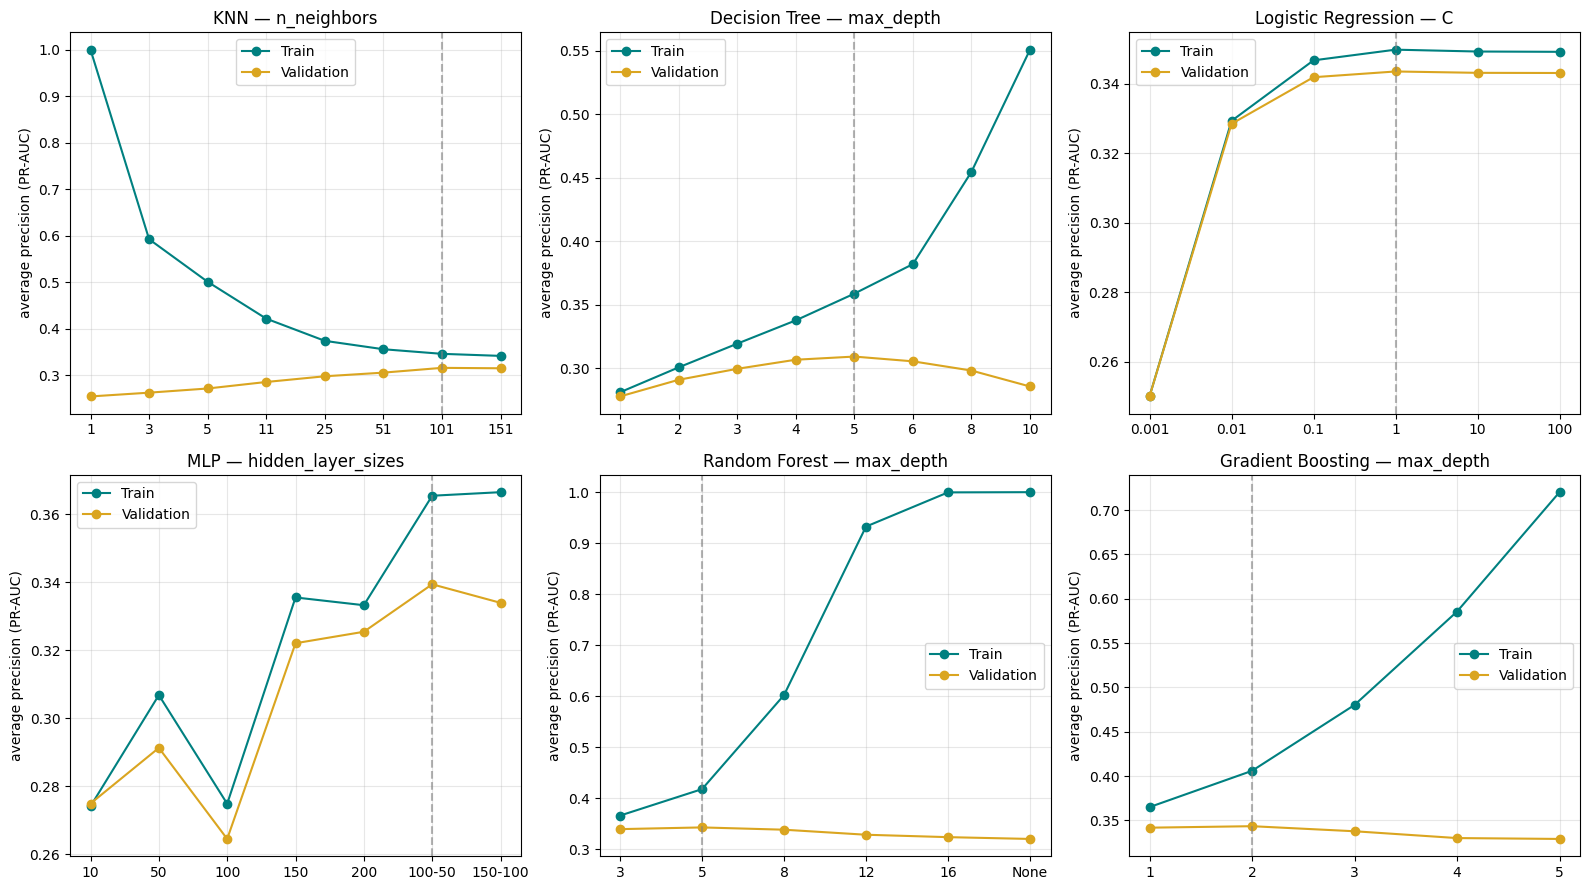

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.ravel()

plot_validation_curve(KNeighborsClassifier(), "n_neighbors",
    [1,3,5,11,25,51,101,151], axes[0], title="KNN — n_neighbors")

plot_validation_curve(DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_SEED),
    "max_depth", [1,2,3,4,5,6,8,10], axes[1], title="Decision Tree — max_depth")

plot_validation_curve(LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000, random_state=RANDOM_SEED),
    "C", [0.001,0.01,0.1,1,10,100], axes[2],
    xticklabels=["0.001","0.01","0.1","1","10","100"], title="Logistic Regression — C")

plot_validation_curve(MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_SEED),
    "hidden_layer_sizes", [(10,),(50,),(100,),(150,),(200,),(100,50),(150,100)], axes[3],
    xticklabels=["10","50","100","150","200","100-50","150-100"], title="MLP — hidden_layer_sizes")

plot_validation_curve(RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1),
    "max_depth", [3,5,8,12,16,None], axes[4],
    xticklabels=["3","5","8","12","16","None"], title="Random Forest — max_depth")

plot_validation_curve(GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "max_depth", [1,2,3,4,5], axes[5], title="Gradient Boosting — max_depth")

plt.tight_layout(); plt.show()

### Validation Curves: Hyperparameter Behaviour and Overfitting

For each model we sweep its main hyperparameter and plot train vs validation PR-AUC (3-fold CV). We use
PR-AUC rather than F1 because it is threshold-independent and is the metric the search optimizes, so the
validation peak (dashed line) marks the selected value. The curves show how each model trades bias for
variance:

- **Logistic Regression** — train and validation overlap and plateau for C >= 0.1: no overfitting, the
  linear model is already at capacity.
- **Decision Tree** — validation peaks around depth 5 then declines while train keeps rising: classic
  overfitting beyond the optimal depth.
- **KNN** — train reaches 1.0 at k = 1 (each point is its own neighbour) and decreases with k, while
  validation rises slowly: small k memorizes, large k regularizes.
- **MLP** — validation peaks at a moderate architecture; larger networks begin to overfit.
- **Random Forest / Gradient Boosting** — train PR-AUC climbs steeply (toward 1.0 for RF) as trees deepen,
  but validation stays flat or peaks early and declines: added complexity buys overfitting, not generalization.

Two takeaways. First, every validation curve flattens or peaks within the same ~0.31–0.35 PR-AUC band,
confirming a performance plateau driven by the features rather than by model capacity. Second, these curves
isolate a single hyperparameter on a simple base configuration, so a peak value here can differ slightly
from the fully optimized model in the comparison table, where all hyperparameters are tuned jointly. Together
with the optimization results, this motivates feature engineering as the next lever for improvement.

In [ ]:
# --- Deployment: train the final model on ALL labelled data, then predict the Kaggle test set ---

# 1. Load the test set and apply the SAME stateless cleaning used on train (no leakage)
test = pd.read_csv(test_path).set_index("CONTROL_NUMBER")
test = clean_impossible_values(test)

# 2. Rebuild the final model (Logistic Regression) with its best params, inside the pipeline
final_estimator = with_best(LogisticRegression(max_iter=2000, random_state=RANDOM_SEED), logreg_result)
final_pipe = Pipeline([("prep", make_preprocessor(keep_features)), ("model", final_estimator)])

# 3. Fit on ALL training data (no CV at deployment) and predict probabilities on the test set
final_pipe.fit(X[keep_features], y)
test_proba = final_pipe.predict_proba(test[keep_features])[:, 1]

# 4. Apply the F1-tuned threshold found during validation
final_threshold = logreg_result["threshold"]
test_pred = (test_proba >= final_threshold).astype(int)

# 5. Build the submission (Kaggle matches by CONTROL_NUMBER, so order does not matter)
submission = pd.DataFrame({"CONTROL_NUMBER": test.index, "TARGET_B": test_pred})
submission.to_csv(lab_root / "DSML_GroupXX.csv", index=False)   # rename XX with your group number
print(submission["TARGET_B"].mean(), "positives |", len(submission), "rows")
submission.head()

0.7653131452167928 positives | 5812 rows


,CONTROL_NUMBER,TARGET_B
0,122653,1
1,184239,1
2,5172,1
3,135377,1
4,62119,1


In [ ]:
# Save the submission with the group's name
output_path = lab_root / "DSML_Group11.csv"
submission.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

# Download it from Colab to your computer
from google.colab import files
files.download(str(output_path))

Saved to /content/drive/MyDrive/Colab Notebooks/DSML/Predictive_Project/DSML_Group11.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
submission.shape

(5812, 2)

In [ ]:
import joblib

# Save the cleaned data (full raw features) and the optimization results, so the
# feature-engineering section can resume without re-running cleaning or the searches.
checkpoint = {
    "train": train,   # cleaned, all raw features + TARGET_B (NaN preserved)
    "test": test,     # cleaned, all raw features
    "results": {"Logistic Regression": logreg_result, "KNN": knn_result, "Decision Tree": dt_result,
                "MLP": mlp_result, "Random Forest": rf_result, "Gradient Boosting": gb_result},
    "keep_features": keep_features,
}
joblib.dump(checkpoint, str(lab_root / "checkpoint_after_modeling.joblib"))
print("Checkpoint saved.")

Checkpoint saved.


In [ ]:
# --- IMPORTS ---
import numpy as np, pandas as pd, joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

# --- CONSTANTS & HELPERS (instant to run) ---
RANDOM_SEED = 99
skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
skf_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
nominal_cat = ["DONOR_GENDER", "HOME_OWNER", "URBANICITY", "RECENCY_STATUS_96NK", "SES"]

def make_preprocessor(features):
    num = [c for c in features if c not in nominal_cat]
    cat = [c for c in features if c in nominal_cat]
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]), num),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat)])

def best_f1_threshold(proba, y_true):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    denom = precision + recall
    f1 = np.divide(2*precision*recall, denom, out=np.zeros_like(denom), where=denom > 0)
    ix = np.argmax(f1[:-1]); return thresholds[ix], f1[ix]

# --- RESUME FROM CHECKPOINT ---
checkpoint = joblib.load(str(lab_root / "checkpoint_after_modeling.joblib"))
train, test = checkpoint["train"], checkpoint["test"]
results, keep_features = checkpoint["results"], checkpoint["keep_features"]
X = train.drop(columns="TARGET_B")
y = train["TARGET_B"]
print("Resumed. X:", X.shape, "| baseline LogReg tuned F1 = 0.4187")

Resumed. X: (13560, 39) | baseline LogReg tuned F1 = 0.4187


In [ ]:
def with_best(base, result):
    """Rebuild an estimator using the best params found by the search (no manual copying)."""
    params = {k.replace("model__", ""): v for k, v in result["best_params"].items()}
    return clone(base).set_params(**params)

In [ ]:
def add_engineered_features(df):
    """RFM-style ratios + log-transforms of skewed monetary features.
       Row-wise / stateless -> safe to apply identically to train and test (no leakage)."""
    df = df.copy()
    eps = 1e-6
    df["LIFETIME_RESPONSE_RATE"] = df["LIFETIME_GIFT_COUNT"] / (df["LIFETIME_PROM"] + eps)
    df["RELATIVE_RECENCY"]       = df["MONTHS_SINCE_LAST_GIFT"] / (df["MONTHS_SINCE_FIRST_GIFT"] + eps)
    df["AVG_LIFETIME_GIFT"]      = df["LIFETIME_GIFT_AMOUNT"] / (df["LIFETIME_GIFT_COUNT"] + eps)
    df["GIFT_TREND"]             = df["LAST_GIFT_AMT"] / (df["RECENT_AVG_GIFT_AMT"] + eps)
    for c in ["RECENT_AVG_GIFT_AMT", "LIFETIME_GIFT_AMOUNT", "MEDIAN_HOME_VALUE", "PER_CAPITA_INCOME"]:
        df["LOG_" + c] = np.log1p(df[c].clip(lower=0))
    return df.replace([np.inf, -np.inf], np.nan)

engineered_features = ["LIFETIME_RESPONSE_RATE", "RELATIVE_RECENCY", "AVG_LIFETIME_GIFT", "GIFT_TREND",
                       "LOG_RECENT_AVG_GIFT_AMT", "LOG_LIFETIME_GIFT_AMOUNT", "LOG_MEDIAN_HOME_VALUE", "LOG_PER_CAPITA_INCOME"]

# Apply to train, evaluate, and compare to baseline
X_eng = add_engineered_features(X)
keep_plus_eng = keep_features + engineered_features

proba = cross_val_predict(Pipeline([("prep", make_preprocessor(keep_plus_eng)),
                                     ("model", with_best(LogisticRegression(max_iter=2000, random_state=RANDOM_SEED), results["Logistic Regression"]))]),
                          X_eng[keep_plus_eng], y, cv=skf, method="predict_proba")[:, 1]
print("Baseline tuned F1:", round(best_f1_threshold(cross_val_predict(
    Pipeline([("prep", make_preprocessor(keep_features)),
              ("model", with_best(LogisticRegression(max_iter=2000, random_state=RANDOM_SEED), results["Logistic Regression"]))]),
    X[keep_features], y, cv=skf, method="predict_proba")[:, 1], y)[1], 4))
print("With engineered tuned F1:", round(best_f1_threshold(proba, y)[1], 4))

Baseline tuned F1: 0.4187
With engineered tuned F1: 0.421


In [ ]:
# --- Deployment with engineered features ---

# 1. Apply the same engineering to train and test (row-wise / stateless)
X_eng    = add_engineered_features(X)
test_eng = add_engineered_features(test)
features_eng = keep_features + engineered_features

# 2. Build the LogReg pipeline and re-tune the threshold on the augmented OOF
final_estimator = with_best(LogisticRegression(max_iter=2000, random_state=RANDOM_SEED), results["Logistic Regression"])
final_pipe = Pipeline([("prep", make_preprocessor(features_eng)), ("model", final_estimator)])
oof = cross_val_predict(final_pipe, X_eng[features_eng], y, cv=skf, method="predict_proba")[:, 1]
final_threshold, _ = best_f1_threshold(oof, y)

# 3. Fit on ALL training data, then predict the test set
final_pipe.fit(X_eng[features_eng], y)
test_proba = final_pipe.predict_proba(test_eng[features_eng])[:, 1]
test_pred = (test_proba >= final_threshold).astype(int)

# 4. Build and save the submission
submission = pd.DataFrame({"CONTROL_NUMBER": test_eng.index, "TARGET_B": test_pred})
submission.to_csv(lab_root / "DSML_Group11_engineered.csv", index=False)
print(submission["TARGET_B"].mean(), "positives |", len(submission), "rows")

0.6608740536820371 positives | 5812 rows


In [ ]:
def add_engineered_features(df):
    """RFM-style ratios, an RFM composite, and log-transforms of skewed features (amounts and counts).
       All row-wise / stateless -> safe to apply identically to train and test (no leakage)."""
    df = df.copy()
    eps = 1e-6
    # ratios
    df["LIFETIME_RESPONSE_RATE"] = df["LIFETIME_GIFT_COUNT"]   / (df["LIFETIME_PROM"] + eps)
    df["RELATIVE_RECENCY"]       = df["MONTHS_SINCE_LAST_GIFT"]/ (df["MONTHS_SINCE_FIRST_GIFT"] + eps)
    df["AVG_LIFETIME_GIFT"]      = df["LIFETIME_GIFT_AMOUNT"]  / (df["LIFETIME_GIFT_COUNT"] + eps)
    df["GIFT_TREND"]             = df["LAST_GIFT_AMT"]         / (df["RECENT_AVG_GIFT_AMT"] + eps)
    df["GIFT_VS_MAX"]            = df["LAST_GIFT_AMT"]         / (df["LIFETIME_MAX_GIFT_AMT"] + eps)
    # RFM composite: frequency * monetary / recency
    df["RFM_COMPOSITE"]          = df["FREQUENCY_STATUS_97NK"] * df["RECENT_AVG_GIFT_AMT"] / (df["MONTHS_SINCE_LAST_GIFT"] + eps)
    # log-transforms of right-skewed features
    for c in ["RECENT_AVG_GIFT_AMT", "LIFETIME_GIFT_AMOUNT", "MEDIAN_HOME_VALUE", "PER_CAPITA_INCOME",
              "LIFETIME_GIFT_COUNT", "LIFETIME_PROM"]:
        df["LOG_" + c] = np.log1p(df[c].clip(lower=0))
    return df.replace([np.inf, -np.inf], np.nan)

engineered_features = ["LIFETIME_RESPONSE_RATE", "RELATIVE_RECENCY", "AVG_LIFETIME_GIFT", "GIFT_TREND",
                       "GIFT_VS_MAX", "RFM_COMPOSITE",
                       "LOG_RECENT_AVG_GIFT_AMT", "LOG_LIFETIME_GIFT_AMOUNT", "LOG_MEDIAN_HOME_VALUE",
                       "LOG_PER_CAPITA_INCOME", "LOG_LIFETIME_GIFT_COUNT", "LOG_LIFETIME_PROM"]

In [ ]:
# --- Deployment with engineered features ---

# 1. Apply the same engineering to train and test (row-wise / stateless)
X_eng    = add_engineered_features(X)
test_eng = add_engineered_features(test)
features_eng = keep_features + engineered_features

# 2. Build the LogReg pipeline and re-tune the threshold on the augmented OOF
final_estimator = with_best(LogisticRegression(max_iter=2000, random_state=RANDOM_SEED), results["Logistic Regression"])
final_pipe = Pipeline([("prep", make_preprocessor(features_eng)), ("model", final_estimator)])
oof = cross_val_predict(final_pipe, X_eng[features_eng], y, cv=skf, method="predict_proba")[:, 1]
final_threshold, _ = best_f1_threshold(oof, y)

# 3. Fit on all training data, then predict the test set
final_pipe.fit(X_eng[features_eng], y)
test_proba = final_pipe.predict_proba(test_eng[features_eng])[:, 1]
test_pred = (test_proba >= final_threshold).astype(int)

# 4. Build and save the submission
submission = pd.DataFrame({"CONTROL_NUMBER": test_eng.index, "TARGET_B": test_pred})
submission.to_csv(lab_root / "DSML_Group11_engineered_v2.csv", index=False)
print(submission["TARGET_B"].mean(), "positives |", len(submission), "rows")

0.7007914659325534 positives | 5812 rows
